# L1 regularization and Lasso: Encouraging sparse solutions

Goals of this notebook:

1. Continue with our exploration of **Regularization**.
2. Explore the setting where we have more degrees of freedom (features) than data points.
3. Explore the concept of Sparsity.
4. An algorithm for finding sparse solutions: LASSO.

In the same way that in Ridge regression we modify the objective, here too we do the same thing, and again with a regularizer. Instead of using the squared Euclidean norm, we use the so-called L1 norm. Thus, instead of solving for the minimizer of the Sum of the Squared Error (SSE), we solve:

$$
\min_{\beta}:\,\, {\rm SSE}(\beta) + \lambda \sum |\beta_i| =  {\rm SSE}(\beta) + \lambda \|\beta\|_1.
$$
$$
\min_{\beta}:\,\, \frac{1}{n} \sum_i (y_i - x_i^{\top}\beta)^2 + \lambda \sum |\beta_i| =  \frac{1}{n} \sum_i (y_i - x_i^{\top}\beta)^2 + \lambda \|\beta\|_1.
$$

This formulation is also called the **LASSO**.

Why should we expect this to encourage sparsity?

In [ ]:
# Import the basics
from __future__ import division
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets, linear_model
import pandas as pd
from pandas import DataFrame, Series
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
sns.set(style='ticks', palette='Set2')
%matplotlib inline

## Generate some sparse data to play with

We create a linear regression data set. A few things to note:

1. The number of features is **larger** than the number of data points: **$d > n$**.
2. The $d$-dimensional vector $\beta$ that we are after, is **sparse** -- most of its entries are zero.


In [ ]:
np.random.seed(7)

n_samples, n_features = 100, 200
X = np.random.randn(n_samples, n_features)

k = 5
# beta generated with k nonzeros
#coef = 10 * np.random.randn(n_features)
coef = 10 * np.ones(n_features)
inds = np.arange(n_features)
np.random.shuffle(inds)
coef[inds[k:]] = 0  # sparsify coef
y = np.dot(X, coef)

# add noise
y += 0.01 * np.random.normal((n_samples,))

# Split data in train set and test set
n_samples = X.shape[0]
X_train, y_train = X[:25], y[:25]
X_test, y_test = X[25:], y[25:]

## Let's see how well we do at recovering $\beta$ when we use

1. Ordinary Least Squares,
2. Ridge Regression,
3. Lasso

We will plot to see how well each is doing in recovering the sparse solution, and we will also see how well each is doing in reducing the **residual error**. This is also measured by what fraction the variation in $y$ is explained by the variation in $x$. This is also sometimes called $R^2$. For this metric, the closer to 1, the BETTER.

## Standard (Ordinary Least Squares) Regression

In [ ]:
# Standard Regression
from sklearn.linear_model import LinearRegression
OLS = LinearRegression()
OLS.fit(X_train,y_train).predict(X_test)
y_pred_OLS = OLS.fit(X_train, y_train).predict(X_test)
r2_score_OLS = r2_score(y_test, y_pred_OLS)
#print(OLS)
print("R^2 on test data : %f" % r2_score_OLS)

R^2 on test data : 0.135512


## The $R^2$ value is not very good. Let's see what the coefficients look like compared to the true coefficients.

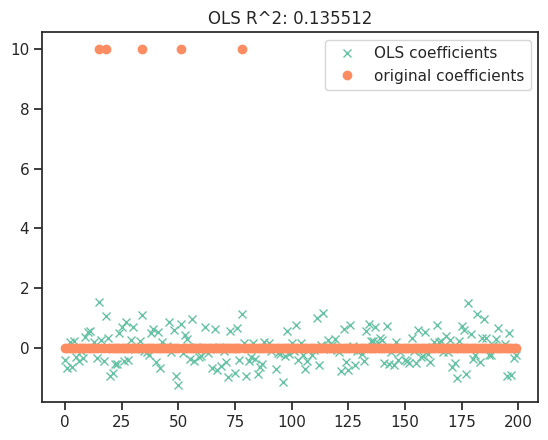

In [ ]:
plt.plot(OLS.coef_,'x', label='OLS coefficients')
plt.plot(coef, 'o', label='original coefficients')
plt.legend(loc='best')
plt.title("OLS R^2: %f"
          % (r2_score_OLS))
plt.show()

In [ ]:
# Let's get the true non-zero coefficients
true_nonzeros = np.where(coef == 10)[0]
true_nonzeros

array([15, 18, 34, 51, 78])

## Ridge Regression

R^2 on test data : 0.135478


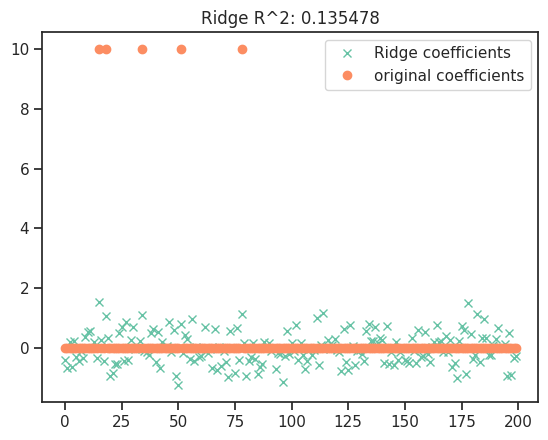

In [ ]:
# Ridge regression
from sklearn.linear_model import Ridge
alpha = 0.1
ridge = Ridge(alpha = alpha)
ridge.fit(X_train,y_train)
y_pred_ridge = ridge.fit(X_train, y_train).predict(X_test)
r2_score_ridge = r2_score(y_test, y_pred_ridge)
#print(lasso)
print("R^2 on test data : %f" % r2_score_ridge)
plt.plot(ridge.coef_, 'x',label='Ridge coefficients')
plt.plot(coef, 'o', label='original coefficients')
plt.legend(loc='best')
plt.title("Ridge R^2: %f"
          % (r2_score_ridge))
plt.show()

## Lasso

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.884e+00, tolerance: 1.128e+00
  model = cd_fast.enet_coordinate_descent(


R^2 on test data : 0.764114


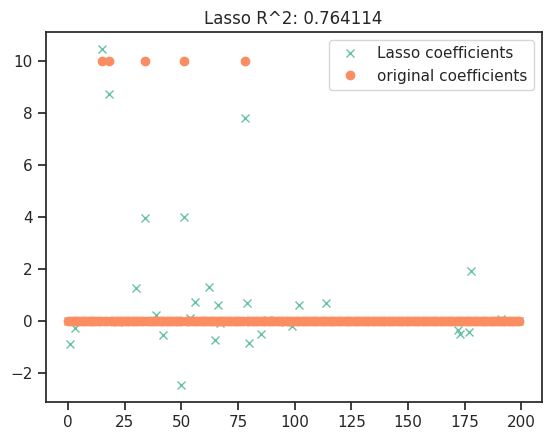

In [ ]:
# Lasso
from sklearn.linear_model import Lasso

lamda = 0.01 # for now, an arbitrary choice
lasso = Lasso(alpha=lamda)

y_pred_lasso = lasso.fit(X_train, y_train).predict(X_test)
r2_score_lasso = r2_score(y_test, y_pred_lasso)
#print(lasso)
print("R^2 on test data : %f" % r2_score_lasso)

# We plot the results
plt.plot(lasso.coef_, 'x',label='Lasso coefficients')
plt.plot(coef, 'o', label='original coefficients')
plt.legend(loc='best')
plt.title("Lasso R^2: %f"
          % (r2_score_lasso))
plt.show()

In [ ]:
# Let's see what the coefficients are. Are they just small, or actually equal to zero?
print('The coefficients LASSO recovers are:', lasso.coef_)
print('The true coefficients are:', coef)

The coefficients LASSO recovers are: [-0.00000000e+00 -8.87532221e-01  0.00000000e+00 -2.66358407e-01
  0.00000000e+00  0.00000000e+00 -0.00000000e+00  0.00000000e+00
 -0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
 -0.00000000e+00  0.00000000e+00 -0.00000000e+00  1.04631328e+01
  0.00000000e+00 -0.00000000e+00  8.71141209e+00  0.00000000e+00
 -0.00000000e+00 -0.00000000e+00 -6.76220890e-02 -0.00000000e+00
  0.00000000e+00  0.00000000e+00 -0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  1.25067199e+00  0.00000000e+00
  0.00000000e+00 -0.00000000e+00  3.94086007e+00  0.00000000e+00
 -0.00000000e+00 -0.00000000e+00  0.00000000e+00  2.11225375e-01
 -0.00000000e+00  0.00000000e+00 -5.58001516e-01  0.00000000e+00
 -0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00 -0.00000000e+00 -2.47834091e+00  4.00763759e+00
 -0.00000000e+00  2.01898262e-03  1.18476643e-01 -0.00000000e+00
  7.28601936e-01  0.00000000e+00  0.00000000e+00 -0.0

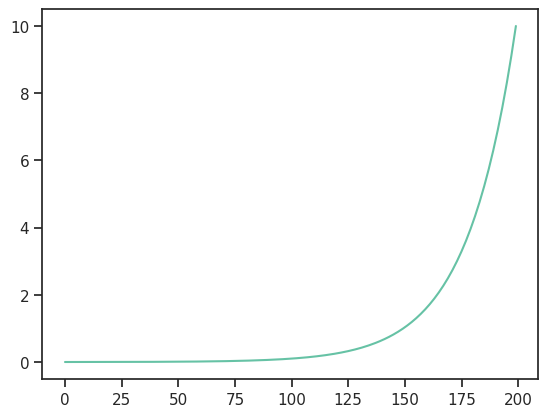

In [ ]:
n_lamdas = 200
lamdas = np.logspace(-3, 1, n_lamdas)
plt.plot(lamdas)
#print(lamdas)

In [ ]:
import warnings
warnings.filterwarnings("ignore")
r_sq = np.ones(lamdas.shape[0])
for i in range(lamdas.shape[0]):
  lamda = lamdas[i]
  lasso.set_params(alpha = lamda)
  lasso.fit(X_train, y_train)
  y_pred_lasso = lasso.fit(X_train, y_train).predict(X_test)
  r2_score_lasso = r2_score(y_test, y_pred_lasso)
  r_sq[i] = r2_score_lasso

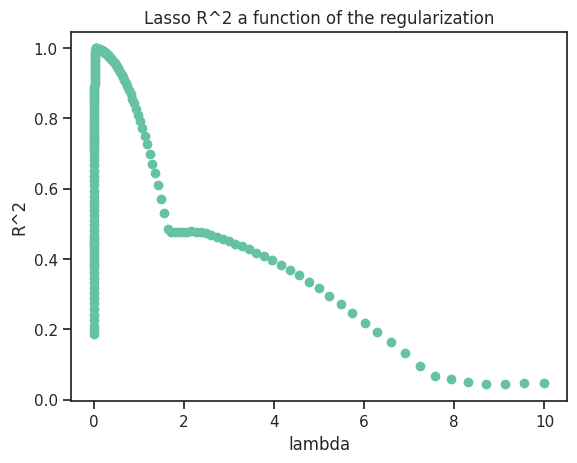

In [ ]:
# Now let's plot the R^2 values
plt.scatter(lamdas,r_sq)
plt.xlabel('lambda')
plt.ylabel('R^2')
plt.title('Lasso R^2 a function of the regularization')
#plt.axis('tight')
plt.show()

In [ ]:
print('The largest value of R^2 is:', max(r_sq))
index_max = np.argmax(r_sq)
print('This occurs at lambda = ', lamdas[index_max])

The largest value of R^2 is: 0.9993425041758525
This occurs at lambda =  0.053535666774107246


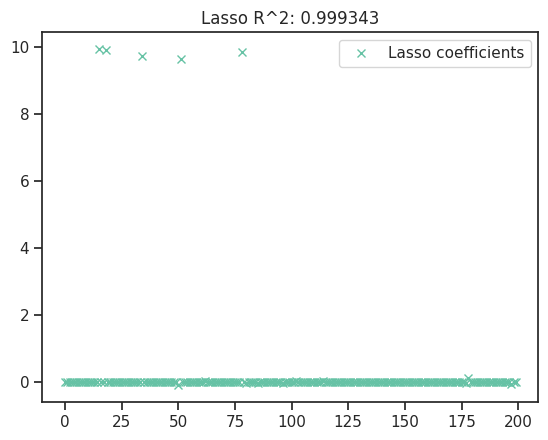

In [ ]:
# Now let's try this value, and see the beta we recover
lamda = lamdas[index_max]
lasso = Lasso(alpha=lamda)

y_pred_lasso = lasso.fit(X_train, y_train).predict(X_test)
r2_score_lasso = r2_score(y_test, y_pred_lasso)
#print(lasso)
plt.plot(lasso.coef_,'x', label='Lasso coefficients')
#plt.plot(coef, 'o', label='original coefficients')
plt.legend(loc='best')
plt.title("Lasso R^2: %f"
          % (r2_score_lasso))
plt.show()

# The Main Takeaway

Regularization is an important tool. Here we have seen that adding a regularizer that penalizes the sum of absolute values of the parameters, encourages the solution to be sparse -- i.e., to have many zeros.

There is considerable theory (beyond the scope of this class) that supports this in certain contexts. However, it is a strategy that is used quite broadly in Machine Learning.
